# EDA — World Health Organization (WHO)

Phân tích `who.json`: loại nội dung, độ phủ thời gian, chất lượng dữ liệu, độ dài bài và mẫu bản ghi.

In [1]:
from pathlib import Path
import sys
search_roots = (Path.cwd(), *Path.cwd().parents)
module_dir = next((p for root in search_roots for p in (root, root / "loc_crawl" / "notebooks") if (p / "eda_utils.py").exists()), None)
if module_dir is None: raise FileNotFoundError("Không tìm thấy eda_utils.py")
sys.path.insert(0, str(module_dir))

from eda_utils import *
SOURCE_KEY = "who"
df, atomic_domains, data_path = load_source(SOURCE_KEY)
print(f"Đã tải {len(df):,} bài từ {data_path}")

Đã tải 2,400 bài từ C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output\who.json


## 1. Tổng quan và mẫu dữ liệu

In [2]:
overview = source_overview(df, atomic_domains, data_path)

**File:** `C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output\who.json`  
**Kích thước:** 14.99 MB

,Chỉ số,Giá trị
0,Số bài,"2,400"
1,Số domain nguyên bản,5
2,Số domain sau khi tách,5
3,Bài đa-domain,0
4,Ngày hợp lệ,"2,400 (100.0%)"
5,Ngày nhỏ nhất,2023-08-19
6,Ngày lớn nhất,2026-07-23
7,ID trùng,0
8,URL trùng,0


,id,source_name,domain,publish_date,claim,label,url
0,21ec1202d0f1c657d30aafd29275318a,WHO,News,2026-07-23,WHO launches seven strategies to prevent drowning,TRUE,https://www.who.int/news/item/23-07-2026-who-launches-seven-strategies-to-prevent-drowning
1,c08d4645179c22ed20d0f5c3ae5fbaa3,WHO,News,2026-07-23,Momentum builds as countries accelerate action to defeat meningitis,TRUE,https://www.who.int/news/item/23-07-2026-momentum-builds-as-countries-accelerate-action-to-defea...
2,2be8a8a571146a4da50d4ceea80d96d1,WHO,News,2026-07-23,Implementing research priorities: webinar explores how global research agendas can lead to meani...,TRUE,https://www.who.int/news/item/23-07-2026-implementing-research-priorities--webinar-explores-how-...
3,1412ecac3f6eb2d1dc514120bb65f355,WHO,News,2026-07-21,"WHO marks 25 years of Research4Life, advancing access to scientific knowledge in more than 120 c...",TRUE,https://www.who.int/news/item/21-07-2026-who-marks-25-years-of-research4life--advancing-access-t...
4,a31beb433079ad141be7400d58d54c50,WHO,Speeches,2026-07-22,WHO Director-General's opening remarks at the Extraordinary Session of the African Union Assembl...,TRUE,https://www.who.int/news-room/speeches/item/who-director-general-s-opening-remarks-at-the-extrao...


## 2. Phân bố domain

**Phân bố domain sau khi tách dấu `;`**

,domain,số_bài,tỷ_lệ_trên_bài
0,News,1513,0.63
1,Speeches,500,0.21
2,Feature stories,285,0.12
3,Statements,98,0.04
4,Emergencies,4,0.00


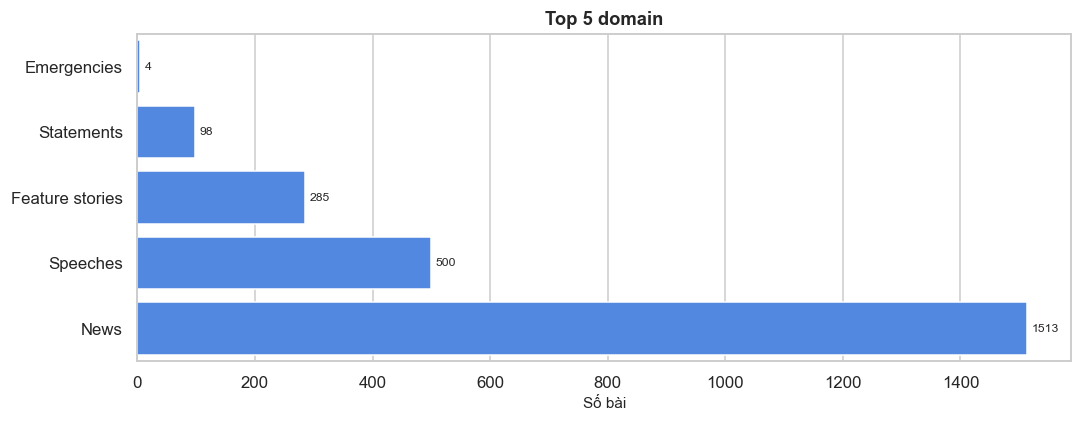

In [3]:
domain_counts = source_domain_analysis(df, atomic_domains)

## 3. Phân bố thời gian và domain theo năm

,trạng_thái_ngày,số_bài,tỷ_lệ
0,Hợp lệ,2400,1.00
1,Thiếu/không parse được,0,0.00


,year,số_bài
0,2023,379
1,2024,831
2,2025,811
3,2026,379


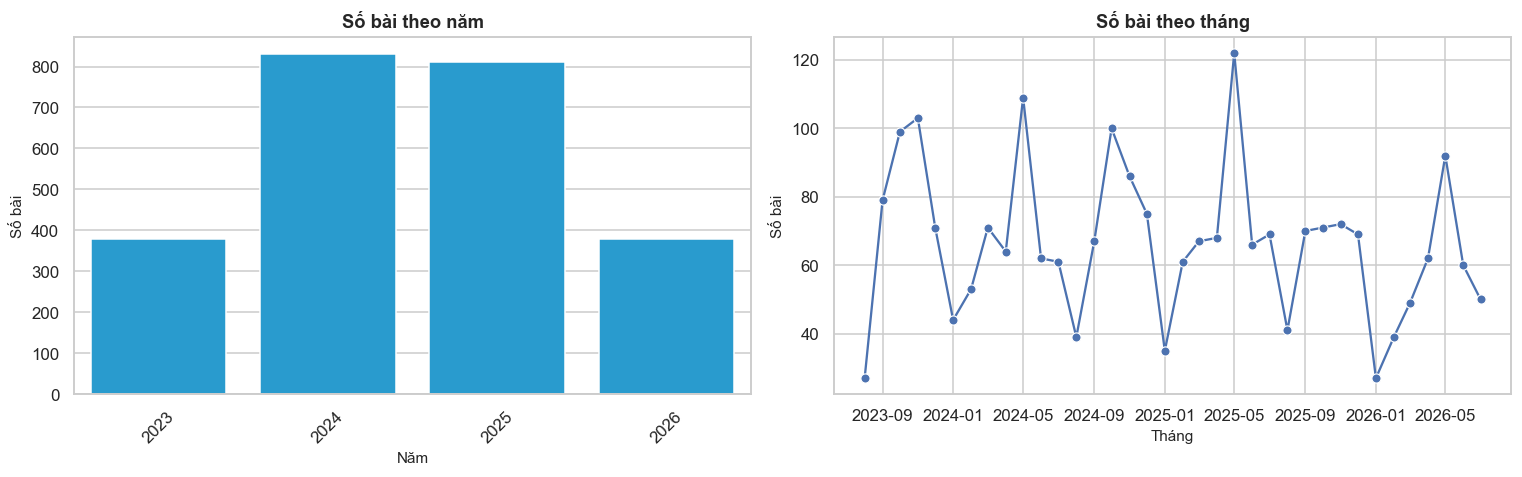

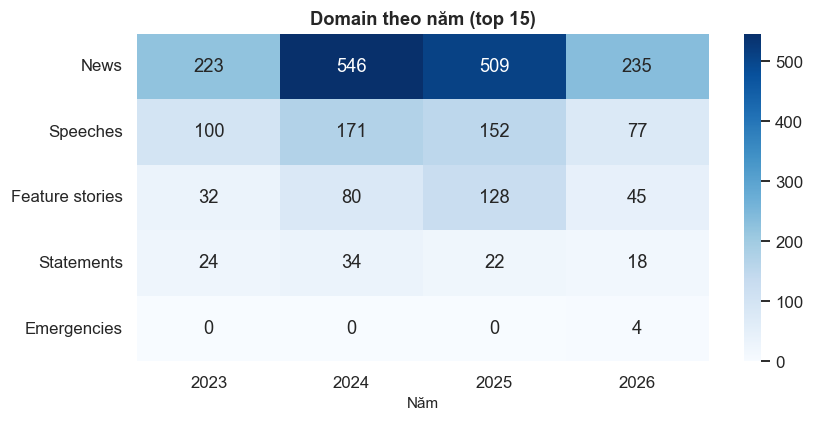

In [4]:
source_timeline(df, atomic_domains)

## 4. Chất lượng dữ liệu

,field,missing,missing_pct
0,comments,2400,100.00
1,original_text,362,15.08
2,claim,0,0.00
3,domain,0,0.00
4,evidence,0,0.00
5,id,0,0.00
6,justification,0,0.00
7,label,0,0.00
8,publish_date,0,0.00
9,source_name,0,0.00


**Trùng lặp và URL**

,khóa,số_dòng_trùng,số_giá_trị_duy_nhất
0,id,0,2400
1,url,0,2400
2,claim,16,2384
3,original_text,69,1969


,chỉ_số,số_bài
0,URL HTTP(S) hợp lệ,2400
1,URL không hợp lệ/thiếu,0
2,Ngày ở tương lai so với hôm nay,0
3,Bài có comments,0


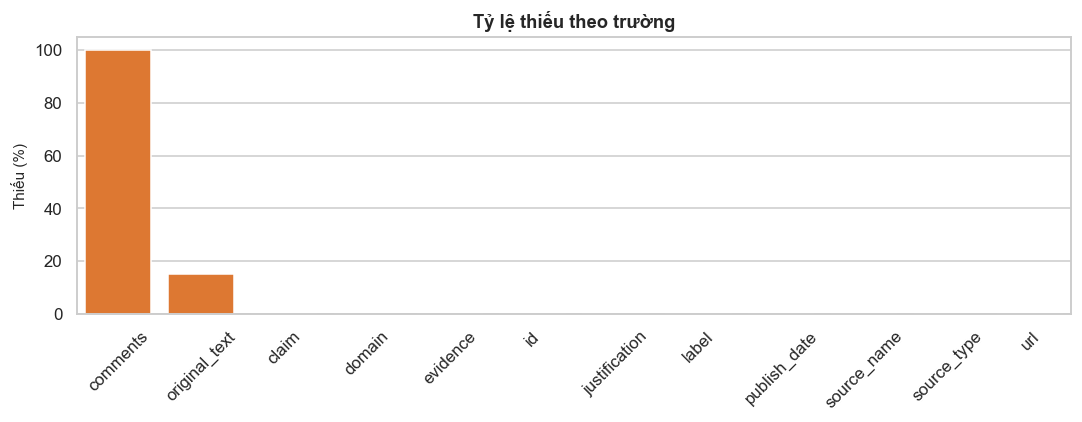

In [5]:
missing = source_quality_analysis(df)

## 5. Độ dài nội dung

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
trường,,,,,,,,,,,
claim_words,"2,400.00",13.27,4.67,3.00,10.00,13.00,16.00,19.00,22.00,27.01,36.00
original_text_words,"2,400.00",122.04,215.71,0.00,23.00,41.00,70.00,447.00,605.10,902.10,"2,200.00"
evidence_words,"2,400.00",9.00,0.00,9.00,9.00,9.00,9.00,9.00,9.00,9.00,9.00
justification_words,"2,400.00",748.05,555.19,30.00,450.00,626.00,857.25,"1,242.00","1,635.25","2,948.85","7,542.00"


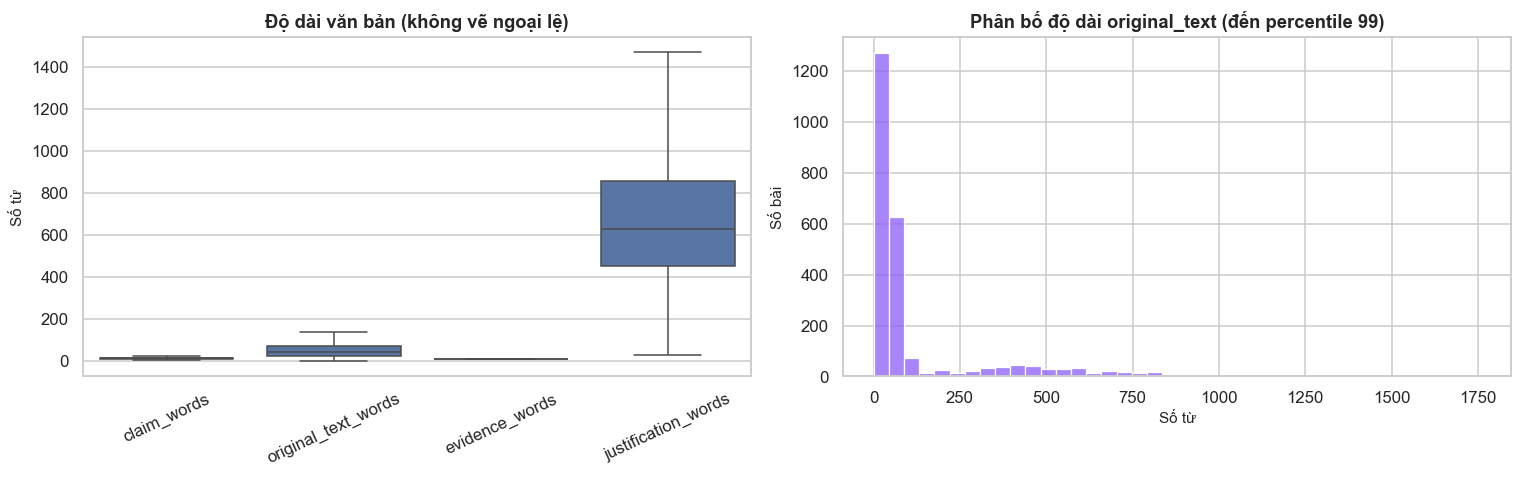

**Độ dài `original_text` theo top domain**

,số_bài,trung_vị,trung_bình,p90
domain_atomic,,,,
Emergencies,4,129.00,155.25,285.60
News,1513,51.00,175.80,560.60
Statements,98,46.00,104.93,124.50
Feature stories,285,40.00,43.99,75.60
Speeches,500,0.00,6.97,27.00


In [6]:
text_summary = source_text_analysis(df, atomic_domains)

## 6. Nhãn, loại nguồn và hostname

In [7]:
source_metadata_analysis(df)

**Nhãn**

,label,số_bài,tỷ_lệ
0,TRUE,2400,1.00


**Loại nguồn**

,source_type,số_bài,tỷ_lệ
0,website,2400,1.00


**Tên nguồn**

,source_name,số_bài,tỷ_lệ
0,WHO,2400,1.00


**Hostname**

,url_host,số_bài,tỷ_lệ
0,who.int,2400,1.00


## 7. Mẫu bài theo domain và nhận xét

In [8]:
samples = source_samples(df, n_per_domain=2)
source_findings(df, atomic_domains)

,domain,publish_date,claim,label,url
0,Emergencies,2026-06-16,At the frontline of trust: a day with Julienne Anoko WHO's Ebola Community Engagement Officer in...,TRUE,https://www.who.int/news/item/16-06-2026-at-the-frontline-of-trust-a-day-with-julienne-anoko-who...
1,Emergencies,2026-07-06,Advancing heat-health preparedness during mass gatherings: practical tools,TRUE,https://www.who.int/news/item/06-07-2026-advancing-heat-health-preparedness-during-mass-gatherin...
2,Feature stories,2023-08-24,"Standing Strong and Brave, Amid Strife",TRUE,https://www.who.int/news-room/feature-stories/detail/standing-strong-and-brave--amid-strife
3,Feature stories,2023-08-30,"Fighting the opioid crisis: the case of Athens, Greece",TRUE,https://www.who.int/news-room/feature-stories/detail/fighting-the-opioid-crisis--the-case-of-ath...
4,News,2023-08-19,"Global partners commit to advance evidence-based traditional, complementary and integrative medi...",TRUE,https://www.who.int/news/item/19-08-2023-global-partners-commit-to-advance-evidence-based-tradit...
5,News,2023-08-19,WHO launches a new Global Initiative on Digital Health supported by the G20 Presidency,TRUE,https://www.who.int/news/item/19-08-2023-who-launches-a-new-global-initiative-on-digital-health-...
6,Speeches,2023-08-19,WHO Director-General's opening remarks at the G20 Health Ministers' meeting - session 2 – 19 Aug...,TRUE,https://www.who.int/news-room/speeches/item/who-director-general-s-opening-remarks-at-the-g20-he...
7,Speeches,2023-08-19,WHO Director-General's opening remarks at the G20 Health Ministers' meeting - session 3 – 19 Aug...,TRUE,https://www.who.int/news-room/speeches/item/who-director-general-s-opening-remarks-at-the-g20-he...
8,Statements,2023-08-25,Statement of the Thirty-sixth Meeting of the Polio IHR Emergency Committee,TRUE,https://www.who.int/news/item/25-08-2023-statement-of-the-thirty-sixth-meeting-of-the-polio-ihr-...
9,Statements,2023-10-10,WHO calls for access to health and humanitarian assistance on fourth day of conflict in Israel a...,TRUE,https://www.who.int/news/item/10-10-2023-who-calls-for-access-to-health-and-humanitarian-assista...


### Nhận xét tự động
- Có **2,400** bài và **5** domain sau khi tách.
- Domain lớn nhất là **News** với **1,513** lượt gán.
- Có **0** bài đa-domain và **0** bài thiếu/không parse được ngày.
- Phân bố nhãn: **TRUE: 2,400**.
- Các nhận xét này là mô tả dữ liệu, không phải kết luận về tính đại diện hay chất lượng nội dung.